# 03 · Shear-thinning fluids

**Problem.** A beverage maker thickens a fruit drink with 0.5 % xanthan gum so that pulp stays suspended on
the shelf, yet the drink must pour and pump easily. Which model describes the flow curve, what are its
parameters (with uncertainties), and what viscosity does the drink have at rest and when poured?

**What you will learn**
- describe shear thinning with the power-law, Cross, Carreau(-Yasuda) and Sisko models
- fit flow curves with uncertainties and compare models with AIC
- explain why fits should use relative (log) residuals
- avoid extrapolating models beyond the data

**Before you start:** notebooks 00-01  ·  **Time:** about 60 min

In [1]:
try:                      # on Google Colab (or anywhere engrheo is missing): install it from GitHub
    import engrheo
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "git+https://github.com/ktwyw/engrheo"], check=True)
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import optimize
from engrheo import datasets, fitting, models
plt.rcParams.update({"figure.figsize": (7, 4), "figure.dpi": 90, "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False})

import inspect
from IPython.display import Code

def show_source(obj):
    """Display the source code of a library function or class."""
    return Code(inspect.getsource(obj), language="python")

def heading(text):
    print(f"\n{text}\n" + "=" * len(text))

In [2]:
df = pd.read_csv(datasets.path("xanthan_flow_curve.csv"), comment="#")
rate, tau = df.shear_rate_1_s.to_numpy(), df.shear_stress_Pa.to_numpy()
fits, table_text = fitting.compare_models(rate, tau, ("power_law", "cross", "carreau", "carreau_yasuda", "sisko"))
print(table_text)

         model  parameters  scatter %     AIC  delta AIC  yield stress
----------------------------------------------------------------------
       carreau           4        1.7  -248.9          0            no
carreau_yasuda           5      1.706  -247.9      1.048            no
         cross           4      7.184  -159.5      89.37            no
     power_law           2      30.96  -70.77      178.1            no
         sisko           3       31.5  -68.77      180.1            no


AIC balances goodness of fit against the number of parameters; differences below about 2 are not
meaningful. The power law and the Sisko model have no low-rate plateau and are far behind. Carreau fits
within the measurement noise (about 2 %); Carreau-Yasuda's extra parameter brings no improvement
($\Delta$AIC about 1), and the Cross model, although it has a plateau, describes this transition clearly worse. Choose
the simplest model that fits within the noise - here Carreau.

carreau fit to 31 points: relative scatter 1.70 %, AIC -248.91
parameter      value  std. error      95% low   95% high
--------------------------------------------------------
     eta0     34.888     0.28238       34.309     35.468
  eta_inf  0.0013695   0.0007017  -7.0296e-05  0.0028092
      lam     11.991     0.22586       11.527     12.454
        n    0.25117   0.0022892      0.24647    0.25586


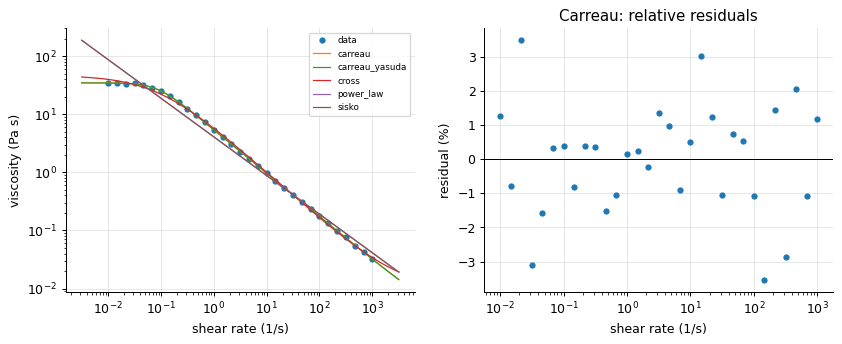

In [3]:
best = next(f for f in fits if f.model == "carreau")
print(best)
rr = np.logspace(-2.5, 3.5, 200)
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 3.8))
a1.loglog(rate, tau / rate, "o", ms=4, label="data")
for f in fits:
    a1.loglog(rr, f.predict_viscosity(rr), lw=1, label=f.model)
a1.set(xlabel="shear rate (1/s)", ylabel="viscosity (Pa s)"); a1.legend(fontsize=7)
a2.semilogx(rate, 100 * best.log_residuals, "o", ms=4); a2.axhline(0, color="k", lw=0.8)
a2.set(xlabel="shear rate (1/s)", ylabel="residual (%)", title="Carreau: relative residuals")
plt.show()

The residuals scatter randomly around zero with no trend - the model describes the data within the
measurement noise. The parameters have a physical meaning: $\eta_0$ is the viscosity at rest, $1/\lambda$ the
shear rate where shear thinning sets in, and $n$ the power-law index at high rates. Note the infinite-shear
viscosity $\eta_\infty$: its confidence interval includes zero, because the data never reach the upper plateau - the
data cannot determine it, and it should not be quoted.

## Why fit on the log scale?
Ordinary least squares on the stress itself minimises *absolute* errors; the high-rate points, whose
stresses are largest, then dominate the fit:

In [4]:
p_lin, _ = optimize.curve_fit(models.carreau, rate, tau, p0=list(best.params.values()),
                              bounds=([0, 0, 0, 0.01], [np.inf, np.inf, np.inf, 1.5]), maxfev=20000)
rel_lin = models.carreau(rate, *p_lin) / tau - 1
rel_log = best.predict_stress(rate) / tau - 1
for name, rel in (("absolute residuals (curve_fit on stress)", rel_lin), ("relative residuals (log scale)", rel_log)):
    print(f"{name:<42}: largest error {np.max(np.abs(rel)):6.1%}, "
          f"below 0.1 1/s {np.max(np.abs(rel[rate < 0.1])):6.1%}")
print(f"eta0: log fit {best.params['eta0']:.2f} Pa s, absolute fit {p_lin[0]:.2f} Pa s")

absolute residuals (curve_fit on stress)  : largest error   6.6%, below 0.1 1/s   6.6%
relative residuals (log scale)            : largest error   3.5%, below 0.1 1/s   3.5%
eta0: log fit 34.89 Pa s, absolute fit 36.06 Pa s


Rheometer errors are roughly proportional to the signal, and flow curves span decades: relative
(logarithmic) residuals give every decade its fair weight.

## The danger of extrapolating a power law

In [5]:
hi = rate >= 10
pl = fitting.fit_flow_curve(rate[hi], tau[hi], "power_law")
for g in (0.01, 1.0, 100.0):
    print(f"at {g:6g} 1/s: power law from 10-1000 1/s predicts {pl.predict_viscosity(g):9.3g} Pa s, "
          f"Carreau {best.predict_viscosity(g):8.3g} Pa s")

at   0.01 1/s: power law from 10-1000 1/s predicts       156 Pa s, Carreau     34.7 Pa s
at      1 1/s: power law from 10-1000 1/s predicts      5.22 Pa s, Carreau     5.42 Pa s
at    100 1/s: power law from 10-1000 1/s predicts     0.175 Pa s, Carreau    0.174 Pa s


Inside its fitting range the power law is excellent; outside it, the error grows without limit, because a
power law has no plateau - its viscosity tends to infinity at zero shear rate. For anything happening at
rest (sedimentation, levelling, sagging) use a model with a zero-shear viscosity, and measure low enough
shear rates to see the plateau.

## Inside the algorithm: a Carreau fit by hand
Minimise the sum of squared log residuals with `scipy.optimize.least_squares`, then estimate standard errors
from the Jacobian, $\text{cov} = s^2 (J^TJ)^{-1}$:

In [6]:
def resid(p):
    return np.log(models.carreau(rate, *p) / tau)
sol = optimize.least_squares(resid, [30, 0.01, 10, 0.3], bounds=([0, 0, 0, 0.01], [np.inf, np.inf, np.inf, 1.5]), x_scale="jac")
s2 = np.sum(sol.fun**2) / (rate.size - 4)
se = np.sqrt(np.diag(s2 * np.linalg.inv(sol.jac.T @ sol.jac)))
print("by hand:", np.round(sol.x, 5), np.round(se, 5))
print("library:", np.round(list(best.params.values()), 5), np.round(list(best.se.values()), 5))

by hand: [3.488816e+01 1.370000e-03 1.199092e+01 2.511700e-01] [0.28238 0.0007  0.22586 0.00229]
library: [3.488816e+01 1.370000e-03 1.199092e+01 2.511700e-01] [0.28238 0.0007  0.22586 0.00229]


## Exercises
1. Fit a power law to the data between 10 and 1000 1/s only. By what factor does it overestimate the viscosity at 0.01 1/s? How does that factor change if you fit from 1 to 1000 1/s instead?
2. Pulp particles (diameter 0.3 mm, 50 kg/m³ denser than the drink) settle under gravity. Estimate the Stokes settling velocity $v = \Delta\rho\, g\, d^2/(18\eta)$ in water and in the xanthan drink (using the viscosity at rest). Check that the shear rate $v/d$ around the particle really lies on the viscosity plateau.
3. **Implement it yourself:** compute AIC $= n\ln(\text{SSR}/n) + 2k$ from the log residuals of the Carreau fit and compare with `best.aic`; then do the same for the power-law fit.